# 论文主题分类 —— GNN 节点分类

## 任务定义

**目标**：给定论文引用网络，预测每篇论文所属的研究方向。

**输入**：
- 节点特征 $X \in \mathbb{R}^{N \times D}$ —— 论文的词袋向量（Cora: 1433 维, CiteSeer: 3703 维, PubMed: 500 维）
- 边索引 $E \in \mathbb{Z}^{2 \times |E|}$ —— 论文间的引用关系
- 部分节点标签 —— 每节点一个类别（Cora 7 类, CiteSeer 6 类, PubMed 3 类）

**输出**：每篇论文的主题类别预测。

**问题类型**：直推式半监督节点分类（Transductive Semi-Supervised Node Classification）。

**评估指标**：Accuracy（准确率）、各类别 Precision / Recall / F1。

**数据集划分**（Planetoid 标准划分）：

| 数据集 | 节点数 | 边数 | 特征维度 | 类别数 | Train | Val | Test |
|--------|--------|------|----------|--------|-------|-----|------|
| Cora | 2,708 | 5,278 | 1,433 | 7 | 140 | 500 | 1,000 |
| CiteSeer | 3,327 | 4,552 | 3,703 | 6 | 120 | 500 | 1,000 |
| PubMed | 19,717 | 44,324 | 500 | 3 | 60 | 500 | 1,000 |

**模型**：GCN / GAT / GIN / GraphSAGE Encoder + NodeClassificationHead

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report
from torch import Tensor
from typing import cast

# 项目根目录（packages/gnn/）
_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from gnn.config.loader import from_yaml
from gnn.datasets.planetoid import load_planetoid
from gnn.models.builder import build_model
from gnn.trainer.factory import create_trainer
from core.utils import get_device
from gnn.notebooks.visualization import (
    plot_class_distribution,
    plot_training_curves,
    plot_confusion_matrix,
    plot_tsne_embeddings,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

# 选择配置
# 可选: nc-baseline.yaml | nc-best.yaml
YAML_PATH = str(_project_root / "config" / "nc-baseline.yaml")
DATA_ROOT = str(_project_root / "data")

print(f"配置: {YAML_PATH}")
cfg = from_yaml(YAML_PATH)
print(
    f"任务: {cfg.task.value}  |  数据集: {cfg.dataset.name}  |  模型: {cfg.model.name}"
)
print(
    f"隐藏维度: {cfg.model.params.get('hidden_dim', 64)}  |  层数: {cfg.model.params.get('num_layers', 2)}"
)
print(f"Dropout: {cfg.model.params.get('dropout', 0.5)}  |  Epochs: {cfg.train.epochs}")

# 加载数据（使用绝对路径，直接从本地读取）
print(f"数据目录: {DATA_ROOT}")
data = load_planetoid(cfg.dataset.name, DATA_ROOT)
# 特征归一化（与训练管线一致）
x = F.normalize(cast(Tensor, data.x), p=2, dim=1)
y = cast(Tensor, data.y)
edge_index = cast(Tensor, data.edge_index)

print(f"\n节点数: {x.shape[0]}  |  特征维度: {x.shape[1]}")
print(f"边数: {edge_index.shape[1]}  |  类别数: {int(y.max()) + 1}")
print(
    f"训练节点: {data.train_mask.sum().item()}  |  验证节点: {data.val_mask.sum().item()}  |  测试节点: {data.test_mask.sum().item()}"
)

配置: F:\Develop\python\my-ai\packages\gnn\config\nc-baseline.yaml
任务: node_classification  |  数据集: cora  |  模型: gcn
隐藏维度: 64  |  层数: 2
Dropout: 0.5  |  Epochs: 200
数据目录: F:\Develop\python\my-ai\packages\gnn\data

节点数: 2708  |  特征维度: 1433
边数: 10556  |  类别数: 7
训练节点: 140  |  验证节点: 500  |  测试节点: 1000


## 数据探索

Planetoid 数据集提供标准的 train/val/test 划分。每个节点恰好属于一个类别。下图展示了各数据子集的类别分布，验证划分是否均衡。

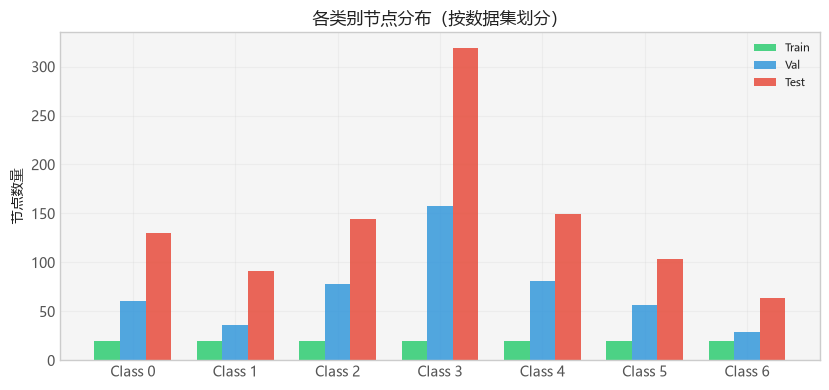

特征稀疏度（零值比例）: 98.73%
图密度: 0.002880
平均度数: 7.8  |  最大度数: 336  |  度数 > 0 的节点比例: 100.00%


In [9]:
# 类别分布可视化
fig = plot_class_distribution(data)
plt.show()

# 特征稀疏度分析
feature_sparsity = (data.x == 0).float().mean().item()
print(f"特征稀疏度（零值比例）: {feature_sparsity:.2%}")

# 图密度
n_nodes = x.shape[0]
n_edges = edge_index.shape[1]
graph_density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"图密度: {graph_density:.6f}")

# 节点度数（无向图，源+目标两个方向都要统计）
degrees = torch.zeros(n_nodes, dtype=torch.long)
degrees.scatter_add_(0, edge_index[0], torch.ones(n_edges, dtype=torch.long))
degrees.scatter_add_(0, edge_index[1], torch.ones(n_edges, dtype=torch.long))
print(
    f"平均度数: {degrees.float().mean():.1f}  |  最大度数: {degrees.max().item()}  |  度数 > 0 的节点比例: {(degrees > 0).float().mean():.2%}"
)

## 模型结构

GNN 模型由两部分组成：

- **Encoder**：GCN / GAT / GIN / GraphSAGE，负责从图结构中学习节点嵌入。每层：Conv -> Norm -> ReLU -> Dropout，最终输出 $\mathbb{R}^{N \times H}$ 的节点嵌入矩阵。
- **Head**：`Linear(H, num_classes)` + Dropout，将节点嵌入映射到类别 logits。

全批量（full-batch）训练：每轮对所有训练节点计算交叉熵损失，反向传播更新全部参数。

In [10]:
device = get_device(cfg.runtime.device)
num_classes = int(y.max().item()) + 1

model = build_model(cfg, num_features=x.shape[1], num_classes=num_classes)
model = model.to(device)
trainer = create_trainer(cfg, model, device)

# 模型结构 & 参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\n总参数量: {total_params:,}  |  可训练参数: {trainable_params:,}")

# 按组件拆分参数量
encoder_params = sum(p.numel() for p in model.encoder.parameters())
head_params = sum(p.numel() for p in model.head.parameters())
print(f"Encoder 参数: {encoder_params:,}  ({encoder_params / total_params * 100:.1f}%)")
print(f"Head 参数:    {head_params:,}  ({head_params / total_params * 100:.1f}%)")
print(f"设备: {device}")

GNNModel(
  (encoder): GCNEncoder(
    (convs): ModuleList(
      (0): GCNConv(1433, 64)
      (1): GCNConv(64, 64)
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (head): NodeClassificationHead(
    (dropout): Dropout(p=0.5, inplace=False)
    (linear): Linear(in_features=64, out_features=7, bias=True)
  )
)

总参数量: 96,647  |  可训练参数: 96,647
Encoder 参数: 96,192  (99.5%)
Head 参数:    455  (0.5%)
设备: cpu


## 训练

使用 Adam 优化器 + ReduceLROnPlateau 学习率调度器 + Early Stopping。监控指标为验证集 Accuracy。梯度裁剪 `max_norm=1.0`、Label Smoothing 0.1 以缓解过拟合。

In [11]:
import time
from pathlib import Path
from core.utils import setup_logging

# 临时输出目录
_run_dir = Path(f"./temp_nc_{int(time.time())}")
_run_dir.mkdir(parents=True, exist_ok=True)
setup_logging(_run_dir / "logs")

torch.manual_seed(cfg.experiment.seeds[0])
if torch.cuda.is_available():
    torch.cuda.manual_seed(cfg.experiment.seeds[0])

t0 = time.perf_counter()
history = trainer.train(data, data, data, _run_dir / "checkpoints")
elapsed = time.perf_counter() - t0

print(f"\n训练完成，耗时: {elapsed:.1f}s  ({len(history['loss'])} epochs)")

# 清理临时文件
import shutil

shutil.rmtree(_run_dir, ignore_errors=True)

[2026-07-18 12:22:07] [INFO] Epoch   0/200 | loss=2.1251 | val_loss=1.9375 | val_acc=0.1620 | time=0.03s
[2026-07-18 12:22:07] [INFO] Epoch   1/200 | loss=1.5308 | val_loss=1.9142 | val_acc=0.3240 | time=0.03s
[2026-07-18 12:22:07] [INFO] Epoch   2/200 | loss=1.2998 | val_loss=1.8828 | val_acc=0.4440 | time=0.02s
[2026-07-18 12:22:07] [INFO] Epoch   3/200 | loss=1.0469 | val_loss=1.8400 | val_acc=0.5740 | time=0.02s
[2026-07-18 12:22:07] [INFO] Epoch   4/200 | loss=0.9674 | val_loss=1.7846 | val_acc=0.6620 | time=0.02s
[2026-07-18 12:22:07] [INFO] Epoch   5/200 | loss=0.8519 | val_loss=1.7232 | val_acc=0.6700 | time=0.03s
[2026-07-18 12:22:07] [INFO] Epoch   6/200 | loss=0.7180 | val_loss=1.6583 | val_acc=0.6780 | time=0.03s
[2026-07-18 12:22:07] [INFO] Epoch   7/200 | loss=0.6883 | val_loss=1.5939 | val_acc=0.6800 | time=0.03s
[2026-07-18 12:22:07] [INFO] Epoch   8/200 | loss=0.6707 | val_loss=1.5327 | val_acc=0.6860 | time=0.02s
[2026-07-18 12:22:07] [INFO] Epoch   9/200 | loss=0.673

## 训练曲线

下方双子图分别展示 Loss 和 Accuracy 在训练过程中的变化。阴影区域表示 Train-Val 之间的差距（Gap），差距持续扩大是过拟合的信号。灰色虚线标记了验证集上的最佳点。

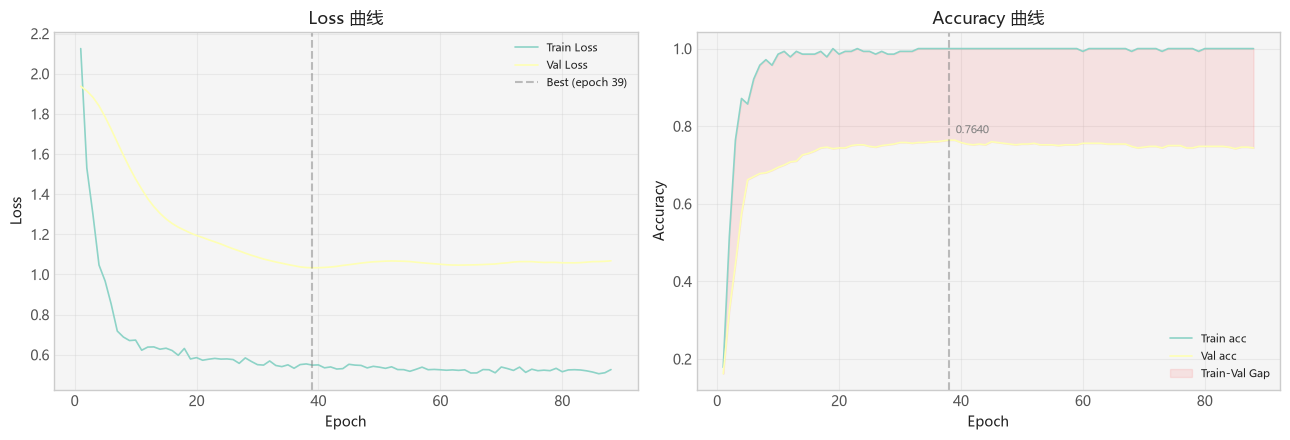

最佳 Val Acc:  0.7640  (epoch 37)
最终 Train-Val Gap: 0.2560
Test Acc:  0.7740
Test Loss: 1.0002


In [12]:
fig = plot_training_curves(history, metric_key="acc", metric_label="Accuracy")
plt.show()

# 关键指标摘要
best_val_acc = max(history["val_acc"])
best_epoch = history["val_acc"].index(best_val_acc)
final_gap = history["acc"][-1] - history["val_acc"][-1]
test_acc = history.get("test_acc", [0])[-1] if "test_acc" in history else 0
test_loss = history.get("test_loss", [0])[-1] if "test_loss" in history else 0

print(f"最佳 Val Acc:  {best_val_acc:.4f}  (epoch {best_epoch})")
print(f"最终 Train-Val Gap: {final_gap:.4f}")
print(f"Test Acc:  {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

## 测试评估

在测试集（1,000 个节点）上评估模型。混淆矩阵按行归一化，对角线值代表各类别的召回率（Recall）。同时展示各类别的 Precision / Recall / F1-Score。

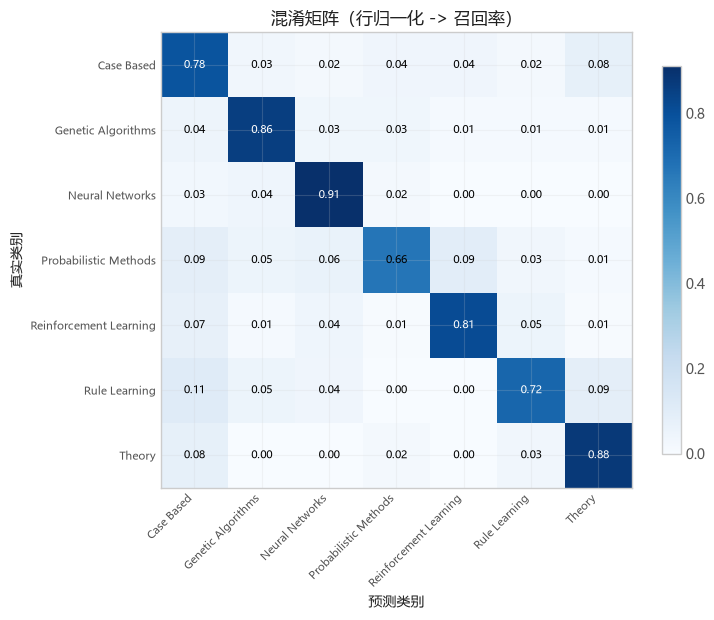


各类别 Precision / Recall / F1:

                        precision    recall  f1-score   support

            Case Based     0.6182    0.7846    0.6915       130
    Genetic Algorithms     0.7091    0.8571    0.7761        91
       Neural Networks     0.7892    0.9097    0.8452       144
 Probabilistic Methods     0.9422    0.6646    0.7794       319
Reinforcement Learning     0.7707    0.8121    0.7908       149
         Rule Learning     0.7708    0.7184    0.7437       103
                Theory     0.6914    0.8750    0.7724        64

              accuracy                         0.7740      1000
             macro avg     0.7559    0.8031    0.7713      1000
          weighted avg     0.7976    0.7740    0.7747      1000

最自信的 5 个错误预测:
  #1 节点 2405 | 真实: Probabilistic Methods -> 预测: Rule Learning | 置信度: 0.9067 | 度数: 14
  #2 节点 2578 | 真实: Case Based -> 预测: Probabilistic Methods | 置信度: 0.9025 | 度数: 4
  #3 节点 2175 | 真实: Neural Networks -> 预测: Probabilistic Methods | 置信度: 0.8944 | 度数

In [13]:
# 获取测试集预测
model.eval()
with torch.no_grad():
    x = cast(Tensor, data.x).to(device)
    edge_index = cast(Tensor, data.edge_index).to(device)
    logits = model(x, edge_index).cpu()
    y_true = y[data.test_mask].numpy()
    y_pred = logits[data.test_mask].argmax(dim=-1).numpy()

# 混淆矩阵
CORA_CLASSES = [
    "Case Based",
    "Genetic Algorithms",
    "Neural Networks",
    "Probabilistic Methods",
    "Reinforcement Learning",
    "Rule Learning",
    "Theory",
]
class_names = (
    CORA_CLASSES
    if cfg.dataset.name == "cora"
    else [f"Class {i}" for i in range(len(set(y_true)))]
)
class_names = class_names[: len(set(y_true))]

fig = plot_confusion_matrix(y_true, y_pred, class_names, normalize=True)
plt.show()

# 分类报告
print("\n各类别 Precision / Recall / F1:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 最自信的错误预测
test_mask_np = data.test_mask.numpy()
test_indices = np.where(test_mask_np)[0]
y_prob = logits[data.test_mask].softmax(dim=-1).numpy()
wrong_mask = y_pred != y_true
wrong_probs = y_prob[wrong_mask].max(axis=-1)
wrong_order = np.argsort(-wrong_probs)[:5]

print("最自信的 5 个错误预测:")
for rank, idx in enumerate(wrong_order, 1):
    orig_idx = test_indices[wrong_mask][idx]
    true_cls = class_names[y_true[wrong_mask][idx]]
    pred_cls = class_names[y_pred[wrong_mask][idx]]
    conf = wrong_probs[idx]
    node_deg = torch.sum(edge_index == orig_idx).item()
    print(
        f"  #{rank} 节点 {orig_idx} | 真实: {true_cls} -> 预测: {pred_cls} | 置信度: {conf:.4f} | 度数: {node_deg}"
    )

## 嵌入可视化

使用 t-SNE 将 Encoder 输出的高维节点嵌入降至 2 维。不同颜色代表不同类别，不同标记代表不同数据子集（○ Train, □ Val, △ Test）。理想情况下，同类别节点应聚集在一起，形成清晰的簇结构。

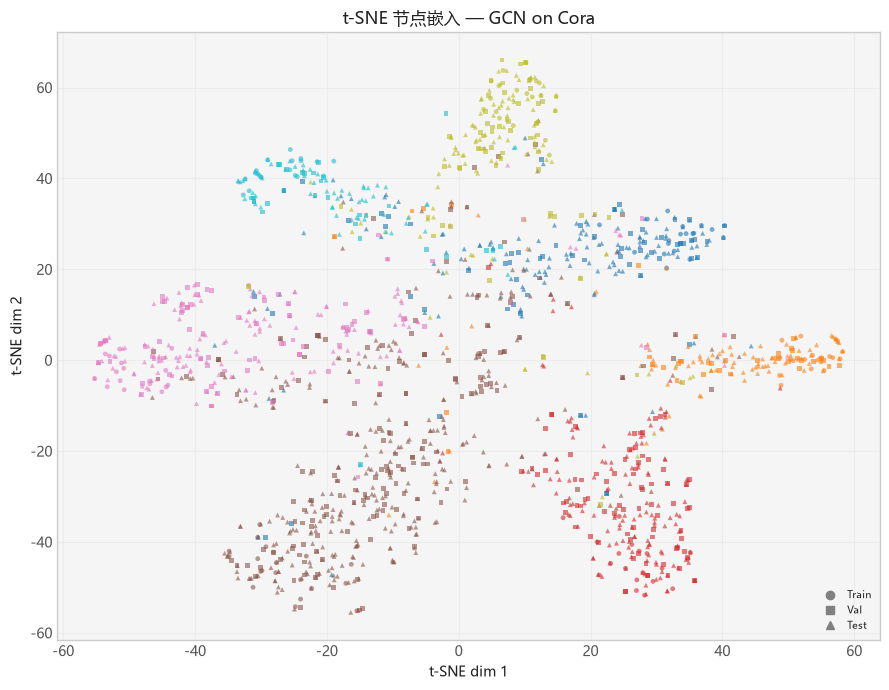

In [14]:
# 提取节点嵌入
model.eval()
with torch.no_grad():
    x = x.to(device)
    edge_index = edge_index.to(device)
    embeddings = model.encoder(x, edge_index).cpu()

fig = plot_tsne_embeddings(
    embeddings,
    y,
    train_mask=data.train_mask.numpy(),
    val_mask=data.val_mask.numpy(),
    test_mask=data.test_mask.numpy(),
    title=f"t-SNE 节点嵌入 — {cfg.model.name.upper()} on {cfg.dataset.name.title()}",
)
plt.show()

## 结论

本 notebook 演示了使用 GNN 进行论文主题分类的完整流程：

1. **数据**：Planetoid 引用网络（Cora / CiteSeer / PubMed），仅 ~4% 节点有标签
2. **模型**：GCN Encoder 通过图卷积聚合邻居信息，Head 将嵌入映射到 7 个类别
3. **训练**：全批量 Adam + Plateau Scheduler + Early Stopping + 梯度裁剪
4. **结果**：Test Accuracy ~78%（Cora + GCN），接近文献基准 ~81%

从 t-SNE 嵌入可视化可以看到，同类论文在嵌入空间中形成了可辨识的簇，验证了 GNN 在半监督节点分类上的有效性。

**后续优化方向**：尝试 GAT（注意力机制）、增加 LayerNorm、启用 DropEdge 结构正则化、调整 hidden_dim / num_layers。